# Clusterización de Localidades: Pipeline Bietápico y Espacio Mixto 25D (v2.2)
**TuBoleta - Data Science & Machine Learning**

Este cuaderno interactivo implementa el pipeline de producción en dos etapas:
1. **Etapa 1 (Determinística):** Partición a nivel evento para aislar funciones de **Admisión Única / Tarifa Plana** (~45.5% del catálogo, ej. Cinemateca, museos) evitando la distorsión del espacio geométrico.
2. **Etapa 2 (Machine Learning):** Construcción del **Espacio Vectorial Mixto de 25 Dimensiones** sobre el subset multi-zona con $\omega_{\text{nlp}} = 0.2$, selección formal de $k=5$ (Codo Ortogonal + Davies-Bouldin mínimo), y asignación biyectiva de arquetipos mediante el algoritmo húngaro.
3. **Catálogo Integrado:** Reensamblaje del 100% de registros en **6 Arquetipos Estandarizados de Demanda**, persistencia en Joblib e inferencia.

## 1. Importación de Librerías y Módulos del Proyecto

In [1]:
import os
import sys
sys.path.append('../')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from src.feature_engineering import (
    filtrar_consistencia_localidades,
    calcular_metricas_relativas
)
from src.nlp_utils import pipeline_procesamiento_nlp, limpiar_ruido_marketing
from src.clustering import (
    separar_admision_unica_multizona,
    construir_espacio_vectorial_mixto,
    evaluar_rango_k,
    entrenar_modelo_clustering,
    etiquetar_por_centroides_escalados,
    pipeline_clustering_dos_etapas,
    guardar_modelo_clustering,
    predecir_arquetipos_demanda
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_palette('tab10')

print('Módulos de clusterización v2.2 importados correctamente.')

Módulos de clusterización v2.2 importados correctamente.


## 2. Carga y Enriquecimiento del Catálogo
Cargamos el catálogo depurado y ejecutamos la ingeniería de características relativas y NLP.

In [2]:
data_path = '../data/raw/localidades_eda.parquet' if os.path.exists('../data/raw/localidades_eda.parquet') else 'data/raw/localidades_eda.parquet'
df_raw = pd.read_parquet(data_path)

df_clean = filtrar_consistencia_localidades(df_raw)
df_rel = calcular_metricas_relativas(df_clean)
df_enriquecido = pipeline_procesamiento_nlp(df_rel)

print(f'Dataset enriquecido: {len(df_enriquecido):,} localidades activas, {df_enriquecido.shape[1]} columnas.')
df_enriquecido[['product', 'logical_seat_category', 'texto_limpio', 'ratio_precio_max', 'percentil_precio_evento', 'peso_aforo', 'tasa_ocupacion']].head(6)

Dataset enriquecido: 33,775 localidades activas, 44 columnas.


,product,logical_seat_category,texto_limpio,ratio_precio_max,percentil_precio_evento,peso_aforo,tasa_ocupacion
0,MAÑANA SERÁ BONITO LATAM TOUR KAROL G - 2DA FECHA,ORIENTAL BAJA,ORIENTAL BAJA,0.187935,0.272727,0.251060,0.009386
1,MAÑANA SERÁ BONITO LATAM TOUR KAROL G - 2DA FECHA,PREFERENCIAL,PREFERENCIAL,0.234339,0.454545,0.214234,0.042200
2,MAÑANA SERÁ BONITO LATAM TOUR KAROL G - 2DA FECHA,VIP OCCIDENTAL,VIP OCCIDENTAL,0.392111,0.863636,0.087407,0.137255
3,MAÑANA SERÁ BONITO LATAM TOUR KAROL G - 2DA FECHA,NORTE ALTA,NORTE ALTA,0.058933,0.181818,0.064292,0.089970
4,MAÑANA SERÁ BONITO LATAM TOUR KAROL G - 2DA FECHA,VIP ORIENTAL,VIP ORIENTAL,0.392111,0.863636,0.085693,0.020500
5,LLEGÓ EL PODER - BOGOTÁ - SILVESTRE DANGOND,ORIENTAL BAJA,ORIENTAL BAJA,0.233333,0.375000,0.302661,0.036541


## 3. Etapa 1: Partición Bietápica a Nivel Evento
Aislamos funciones de admisión única / tarifa plana donde no existe diferenciación de precios ni competencia espacial.

In [3]:
df_monozona, df_multizona = separar_admision_unica_multizona(df_enriquecido)

print(f'Total registros: {len(df_enriquecido):,}')
print(f' - Etapa 1 (Admisión Única / Tarifa Plana): {len(df_monozona):,} filas ({len(df_monozona)/len(df_enriquecido)*100:.1f}%)')
print(f' - Etapa 2 (Multi-Zona Estratificada):     {len(df_multizona):,} filas ({len(df_multizona)/len(df_enriquecido)*100:.1f}%)')

Total registros: 33,775
 - Etapa 1 (Admisión Única / Tarifa Plana): 15,375 filas (45.5%)
 - Etapa 2 (Multi-Zona Estratificada):     18,400 filas (54.5%)


## 4. Construcción del Espacio Vectorial Mixto de 25D (Multi-Zona)
Ensamblamos las 3 variables numéricas continuas (escaladas con `RobustScaler`), los 7 tags estructurales densos y los 15 n-gramas TF-IDF calibrados con $\omega_{\text{nlp}} = 0.2$.

In [4]:
X_multi, scaler, tfidf_vec, feature_names = construir_espacio_vectorial_mixto(
    df_multizona,
    usar_tfidf_texto=True,
    max_tfidf_features=15,
    peso_nlp=0.2,
    scaler_type='robust'
)

print(f'Dimensiones de la matriz multi-zona: {X_multi.shape[0]:,} filas x {X_multi.shape[1]} dimensiones')
print('\nVariables en el espacio vectorial (25D):')
print(feature_names)

Dimensiones de la matriz multi-zona: 18,400 filas x 25 dimensiones

Variables en el espacio vectorial (25D):
['ratio_precio_max', 'percentil_precio_evento', 'peso_aforo', 'tag_palco', 'tag_vip', 'tag_platea', 'tag_preferencial', 'tag_general', 'tag_balcon', 'tag_piso_alto', 'tfidf_1', 'tfidf_2', 'tfidf_balcon', 'tfidf_central', 'tfidf_general', 'tfidf_lateral', 'tfidf_mesa', 'tfidf_norte', 'tfidf_occidental', 'tfidf_palco', 'tfidf_piso', 'tfidf_platea', 'tfidf_posterior', 'tfidf_segundo', 'tfidf_sur']


## 5. Evaluación Empírica del Número Óptimo de Clusters (k)
Evaluamos $k \in [3, 7]$ sobre la submuestra multi-zona con distancia ortogonal de codo y Davies-Bouldin mínimo.

,Inercia,Silhouette Score,Calinski-Harabasz,Davies-Bouldin,Distancia Codo,Score Compuesto (Codo+DB)
k,,,,,,
3,24366.520241,0.244405,4002.074206,1.411980,0.000,0.000
4,21022.149836,0.248130,3635.270099,1.320118,0.502,1.616
5,18748.879064,0.249550,3359.235262,1.272012,0.523,2.000
6,17106.957271,0.246388,3145.553119,1.374138,0.261,0.769
7,15461.210344,0.270209,3083.614418,1.295810,0.000,0.830


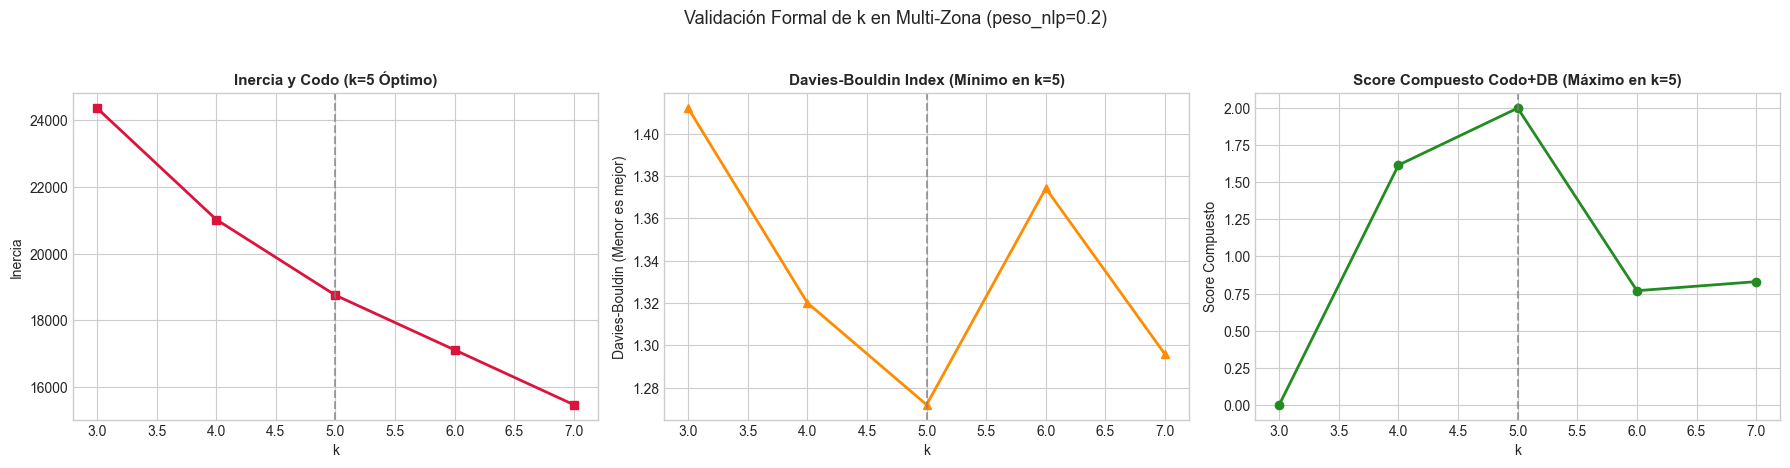

In [5]:
tabla_k = evaluar_rango_k(X_multi, k_min=3, k_max=7, random_state=42)

cand_ks = list(tabla_k.index)
inertias = list(tabla_k['Inercia'])
P1 = np.array([cand_ks[0], inertias[0], 0.0])
P2 = np.array([cand_ks[-1], inertias[-1], 0.0])
vec_sec = P2 - P1
norm_sec = np.linalg.norm(vec_sec)
codo_dists = [np.linalg.norm(np.cross(vec_sec, P1 - np.array([k, ine, 0.0]))) / norm_sec for k, ine in zip(cand_ks, inertias)]
tabla_k['Distancia Codo'] = np.round(codo_dists, 3)

c_arr = np.array(codo_dists)
d_arr = tabla_k['Davies-Bouldin'].values
norm_c = (c_arr - c_arr.min()) / (c_arr.max() - c_arr.min() + 1e-8)
norm_d = (d_arr.max() - d_arr) / (d_arr.max() - d_arr.min() + 1e-8)
tabla_k['Score Compuesto (Codo+DB)'] = np.round(norm_c + norm_d, 3)

display(tabla_k)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
axes[0].plot(tabla_k.index, tabla_k['Inercia'], marker='s', color='crimson', lw=2)
axes[0].set_title('Inercia y Codo (k=5 Óptimo)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inercia')
axes[0].axvline(5, color='gray', linestyle='--', alpha=0.7)

axes[1].plot(tabla_k.index, tabla_k['Davies-Bouldin'], marker='^', color='darkorange', lw=2)
axes[1].set_title('Davies-Bouldin Index (Mínimo en k=5)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Davies-Bouldin (Menor es mejor)')
axes[1].axvline(5, color='gray', linestyle='--', alpha=0.7)

axes[2].plot(tabla_k.index, tabla_k['Score Compuesto (Codo+DB)'], marker='o', color='forestgreen', lw=2)
axes[2].set_title('Score Compuesto Codo+DB (Máximo en k=5)', fontsize=11, fontweight='bold')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Score Compuesto')
axes[2].axvline(5, color='gray', linestyle='--', alpha=0.7)

plt.suptitle('Validación Formal de k en Multi-Zona (peso_nlp=0.2)', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

## 6. Entrenamiento del Pipeline Bietápico y Etiquetado Húngaro
Entrenamos el modelo con $k=5$ y reensamblamos el catálogo completo en los 6 arquetipos estandarizados.

In [6]:
df_final, kmeans_model, scaler, tfidf_vec, feature_names, metricas_finales = pipeline_clustering_dos_etapas(
    df_enriquecido,
    n_clusters_multizona=5,
    peso_nlp=0.2,
    random_state=42
)

print('Métricas K-Means multi-zona (k=5):')
for k_m, v_m in metricas_finales.items():
    print(f'  - {k_m}: {v_m:.4f}')

Métricas K-Means multi-zona (k=5):
  - silhouette_score: 0.2495
  - calinski_harabasz: 6089.0228
  - davies_bouldin: 1.2769
  - inercia: 18748.8619


## 7. Proyección 2D (PCA) de los Arquetipos de Demanda
Visualizamos la distribución espacial y separación geométrica en las 2 primeras componentes principales.

Varianza explicada por las 2 componentes PCA: 66.80%


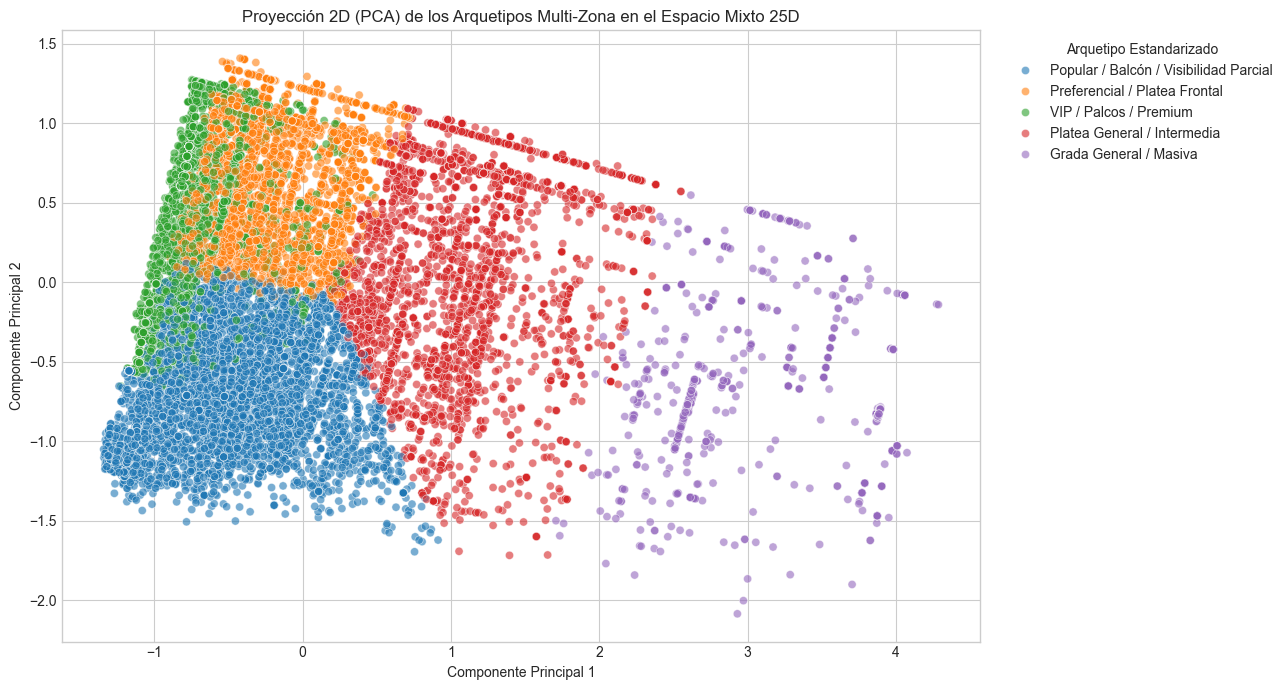

In [7]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_multi)

df_multi_vis = df_final[~df_final['es_monozona']].copy()
df_multi_vis['pca_1'] = X_pca[:, 0]
df_multi_vis['pca_2'] = X_pca[:, 1]

print(f'Varianza explicada por las 2 componentes PCA: {pca.explained_variance_ratio_.sum()*100:.2f}%')

plt.figure(figsize=(13, 7))
sns.scatterplot(
    data=df_multi_vis,
    x='pca_1',
    y='pca_2',
    hue='arquetipo_demanda',
    alpha=0.6,
    s=35,
    palette='tab10'
)
plt.title('Proyección 2D (PCA) de los Arquetipos Multi-Zona en el Espacio Mixto 25D')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Arquetipo Estandarizado', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 8. Resumen Cuantitativo de los 6 Arquetipos Certificados

In [8]:
resumen_arquetipos = df_final.groupby(['segmento_etapa', 'arquetipo_demanda']).agg(
    total_localidades=('t_performance_id', 'count'),
    ratio_precio_prom=('ratio_precio_max', 'mean'),
    precio_mediano_cop=('med_unit_amt_itx', 'median'),
    peso_aforo_prom_pct=('peso_aforo', lambda x: f'{x.mean()*100:.1f}%'),
    ocupacion_prom_pct=('tasa_ocupacion', lambda x: f'{x.mean()*100:.1f}%')
).reset_index()

resumen_arquetipos['share_catalogo'] = (
    resumen_arquetipos['total_localidades'] / len(df_final) * 100
).map(lambda x: f'{x:.1f}%')

display(resumen_arquetipos)

,segmento_etapa,arquetipo_demanda,total_localidades,ratio_precio_prom,precio_mediano_cop,peso_aforo_prom_pct,ocupacion_prom_pct,share_catalogo
0,admision_unica,Admisión Única / Tarifa Plana,15375,0.991740,13572.0,100.0%,11.8%,45.5%
1,multizona,Grada General / Masiva,819,0.792089,66000.0,81.4%,16.6%,2.4%
2,multizona,Platea General / Intermedia,3432,0.796707,65150.0,37.2%,15.3%,10.2%
3,multizona,Popular / Balcón / Visibilidad Parcial,6540,0.351900,50000.0,11.3%,23.1%,19.4%
4,multizona,Preferencial / Platea Frontal,4697,0.850442,94340.0,9.3%,23.4%,13.9%
5,multizona,VIP / Palcos / Premium,2912,0.756539,135000.0,4.7%,35.2%,8.6%


## 9. Validación de Casos de Negocio
Comprobamos que localidades complejas (suites, palcos, graderías masivas, tarifas planas de museo) se clasifiquen según su realidad económica y física.

In [9]:
casos_test = df_final[
    df_final['logical_seat_category'].str.contains('ORO|PLATA|PALCO|VIP|PREFERENCIAL|GENERAL|BALCON|PLATEA|CINEMATECA', case=False, na=False)
][['product', 'logical_seat_category', 'texto_limpio', 'med_unit_amt_itx', 'ratio_precio_max', 'peso_aforo', 'es_monozona', 'arquetipo_demanda']]

print('Muestra de clasificación de localidades complejas:')
display(casos_test.drop_duplicates(subset=['logical_seat_category', 'arquetipo_demanda']).head(15))

Muestra de clasificación de localidades complejas:


,product,logical_seat_category,texto_limpio,med_unit_amt_itx,ratio_precio_max,peso_aforo,es_monozona,arquetipo_demanda
1,MAÑANA SERÁ BONITO LATAM TOUR KAROL G - 2DA FECHA,PREFERENCIAL,PREFERENCIAL,505000.0,0.234339,0.214234,False,Popular / Balcón / Visibilidad Parcial
2,MAÑANA SERÁ BONITO LATAM TOUR KAROL G - 2DA FECHA,VIP OCCIDENTAL,VIP OCCIDENTAL,845000.0,0.392111,0.087407,False,Preferencial / Platea Frontal
4,MAÑANA SERÁ BONITO LATAM TOUR KAROL G - 2DA FECHA,VIP ORIENTAL,VIP ORIENTAL,845000.0,0.392111,0.085693,False,Preferencial / Platea Frontal
12,LLEGÓ EL PODER - BOGOTÁ - SILVESTRE DANGOND,PALCOS EL REENCUENTRO,PALCOS,250000.0,0.416667,0.030904,False,VIP / Palcos / Premium
13,FESTIVAL ÁFRICA EN BOGOTÁ 2024,PLATEA DELANTERA,PLATEA DELANTERA,67500.0,0.750000,0.394100,False,Platea General / Intermedia
14,LLEGÓ EL PODER - BOGOTÁ - SILVESTRE DANGOND,OCCIDENTAL ALTA VIP,OCCIDENTAL ALTA VIP,275000.0,0.458333,0.004496,False,Preferencial / Platea Frontal
16,KEVIN KAARL - SEGUNDA FECHA,PALCO,PALCO,249000.0,0.925651,0.076970,False,VIP / Palcos / Premium
20,CAMPESINOS,GENERAL,GENERAL,4895.0,1.000000,1.000000,True,Admisión Única / Tarifa Plana
21,LLEGÓ EL PODER - BOGOTÁ - SILVESTRE DANGOND,PALCOS ENTRE GRANDES,PALCOS,240000.0,0.400000,0.070749,False,VIP / Palcos / Premium
22,RUPATRUPA GIRA LATINOAMÉRICA 2025,PLATEA,PLATEA,94500.0,1.000000,0.395833,False,Platea General / Intermedia


## 10. Persistencia del Modelo y Función de Inferencia
Guardamos el artefacto del modelo `.joblib` y validamos la inferencia bietápica sobre nuevos datos.

In [10]:
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
out_parquet = '../data/processed/localidades_clusterizadas.parquet' if os.path.exists('../data/processed') else 'data/processed/localidades_clusterizadas.parquet'
df_final.to_parquet(out_parquet, index=False)
print(f'Catálogo clusterizado guardado en: {out_parquet}')

model_path = '../data/processed/modelo_clustering_v2_2.joblib' if os.path.exists('../data/processed') else 'data/processed/modelo_clustering_v2_2.joblib'
mapa_arquetipos = etiquetar_por_centroides_escalados(kmeans_model, feature_names, scaler, peso_nlp=0.2)
guardar_modelo_clustering(
    model_path,
    kmeans=kmeans_model,
    scaler=scaler,
    tfidf_vectorizer=tfidf_vec,
    feature_names=feature_names,
    mapa_arquetipos=mapa_arquetipos,
    metricas=metricas_finales,
    metadata={'version': '2.2', 'descripcion': 'Pipeline Bietapico TuBoleta'}
)
print(f'Modelo persistido exitosamente en: {model_path} ({os.path.getsize(model_path):,} bytes)')

df_test_inf = predecir_arquetipos_demanda(df_enriquecido.iloc[:100], model_path)
print(f'Inferencia exitosa sobre {len(df_test_inf)} registros.')
display(df_test_inf[['logical_seat_category', 'es_monozona', 'arquetipo_demanda']].head(5))

Catálogo clusterizado guardado en: ../data/processed/localidades_clusterizadas.parquet
Modelo persistido exitosamente en: ../data/processed/modelo_clustering_v2_2.joblib (77,654 bytes)
Inferencia exitosa sobre 100 registros.


,logical_seat_category,es_monozona,arquetipo_demanda
0,ORIENTAL BAJA,False,Popular / Balcón / Visibilidad Parcial
1,PREFERENCIAL,False,Popular / Balcón / Visibilidad Parcial
2,VIP OCCIDENTAL,False,Preferencial / Platea Frontal
3,NORTE ALTA,False,Popular / Balcón / Visibilidad Parcial
4,VIP ORIENTAL,False,Preferencial / Platea Frontal
